In [1]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = os.path.expanduser("~/.config/gcloud/application_default_credentials.json")

from pyspark.sql import SparkSession
import pyspark.sql.functions as F

spark = (
    SparkSession.builder
    .appName("goodreads_eda")
    .config("spark.driver.memory", "4g")
    .config("spark.hadoop.fs.gs.impl", "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem")
    .config("spark.hadoop.fs.gs.auth.type", "APPLICATION_DEFAULT")
    .getOrCreate()
)

GCS_BASE = "gs://nshen7-personal-bucket/projects/rec_sys_goodreads"

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/02/10 22:58:31 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
import matplotlib.pyplot as plt
import numpy as np

The downloaded raw data files in GCS (`gs://nshen7-personal-bucket/projects/rec_sys_goodreads/data/raw`):

+ Detailed book graph (~2gb, about 2.3m books): `goodreads_books.json.gz`
+ Complete user-book interactions in 'csv' format (~4.1gb): `goodreads_interactions.csv`
+ Detailed information of the complete user-book interactions (~11gb, ~229m records, with timestamp): `goodreads_interactions_dedup.json.gz`
+ User Ids and Book Ids in this file can be reconstructed by joining on the following two files: `book_id_map.csv`, `user_id_map.csv`.

Sample records are displayed in `https://github.com/MengtingWan/goodreads/blob/master/samples.ipynb`


In [3]:
# One-time conversion: CSV/JSON -> Parquet (run once, then skip this cell)
PARQUET_BASE = f"{GCS_BASE}/data/parquet"

# spark.read.json(f"{GCS_BASE}/data/raw/goodreads_books.json.gz") \
#     .write.mode("overwrite").parquet(f"{PARQUET_BASE}/books")

# spark.read.csv(f"{GCS_BASE}/data/raw/goodreads_interactions.csv", header=True, inferSchema=True) \
#     .write.mode("overwrite").parquet(f"{PARQUET_BASE}/interactions")

# spark.read.json(f"{GCS_BASE}/data/raw/goodreads_interactions_dedup.json.gz") \
#     .write.mode("overwrite").parquet(f"{PARQUET_BASE}/goodreads_interactions_dedup")

# spark.read.csv(f"{GCS_BASE}/data/raw/book_id_map.csv", header=True, inferSchema=True) \
#     .write.mode("overwrite").parquet(f"{PARQUET_BASE}/book_id_map")

# spark.read.csv(f"{GCS_BASE}/data/raw/user_id_map.csv", header=True, inferSchema=True) \
#     .write.mode("overwrite").parquet(f"{PARQUET_BASE}/user_id_map")

print("Parquet conversion done.")

26/02/10 23:00:56 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Parquet conversion done.


In [2]:
# Load ALL parquet datasets
PARQUET_BASE = f"{GCS_BASE}/data/parquet"

interactions = spark.read.parquet(f"{PARQUET_BASE}/interactions")
book_id_map = spark.read.parquet(f"{PARQUET_BASE}/book_id_map")
user_id_map = spark.read.parquet(f"{PARQUET_BASE}/user_id_map")
books = spark.read.parquet(f"{PARQUET_BASE}/books")
interactions_dedup = spark.read.parquet(f"{PARQUET_BASE}/goodreads_interactions_dedup")

## 1. Schema & Shape Overview (All Datasets)

In [4]:
datasets = {
    "interactions": interactions,
    "book_id_map": book_id_map,
    "user_id_map": user_id_map,
    "books": books,
    "interactions_dedup": interactions_dedup,
}

for name, df in datasets.items():
    print(f"{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"Rows: {df.count():,}  |  Columns: {len(df.columns)}")
    df.printSchema()
    df.show(5, truncate=80)
    print()

  interactions


Rows: 228,648,342  |  Columns: 5
root
 |-- user_id: integer (nullable = true)
 |-- book_id: integer (nullable = true)
 |-- is_read: integer (nullable = true)
 |-- rating: integer (nullable = true)
 |-- is_reviewed: integer (nullable = true)



+-------+-------+-------+------+-----------+
|user_id|book_id|is_read|rating|is_reviewed|
+-------+-------+-------+------+-----------+
|      0|    948|      1|     5|          0|
|      0|    947|      1|     5|          1|
|      0|    946|      1|     5|          0|
|      0|    945|      1|     5|          0|
|      0|    944|      1|     5|          0|
+-------+-------+-------+------+-----------+
only showing top 5 rows

  book_id_map
Rows: 2,360,650  |  Columns: 2
root
 |-- book_id_csv: integer (nullable = true)
 |-- book_id: integer (nullable = true)

+-----------+--------+
|book_id_csv| book_id|
+-----------+--------+
|          0|34684622|
|          1|34536488|
|          2|34017076|
|          3|   71730|
|          4|30422361|
+-----------+--------+
only showing top 5 rows

  user_id_map
Rows: 876,145  |  Columns: 2
root
 |-- user_id_csv: integer (nullable = true)
 |-- user_id: string (nullable = true)

+-----------+--------------------------------+
|user_id_csv|           

26/02/06 21:29:59 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


Rows: 2,360,655  |  Columns: 29
root
 |-- asin: string (nullable = true)
 |-- authors: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- author_id: string (nullable = true)
 |    |    |-- role: string (nullable = true)
 |-- average_rating: string (nullable = true)
 |-- book_id: string (nullable = true)
 |-- country_code: string (nullable = true)
 |-- description: string (nullable = true)
 |-- edition_information: string (nullable = true)
 |-- format: string (nullable = true)
 |-- image_url: string (nullable = true)
 |-- is_ebook: string (nullable = true)
 |-- isbn: string (nullable = true)
 |-- isbn13: string (nullable = true)
 |-- kindle_asin: string (nullable = true)
 |-- language_code: string (nullable = true)
 |-- link: string (nullable = true)
 |-- num_pages: string (nullable = true)
 |-- popular_shelves: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- count: string (nullable = true)
 |    |    |-- name: s

+----------+------------+--------------+-------+------------+--------------------------------------------------------------------------------+-------------------+---------+--------------------------------------------------------------------------------+--------+----------+-------------+-----------+-------------+-----------------------------------------------------------------+---------+--------------------------------------------------------------------------------+---------------+-----------------+----------------+----------------------+-------------+--------+--------------------------------------------------------------------------------+------------------+--------------------------------------------------------------------+--------------------------------------------------------------------+-----------------------------------------------------------------+-------+
|      asin|     authors|average_rating|book_id|country_code|                                                           

Rows: 228,648,342  |  Columns: 10
root
 |-- book_id: string (nullable = true)
 |-- date_added: string (nullable = true)
 |-- date_updated: string (nullable = true)
 |-- is_read: boolean (nullable = true)
 |-- rating: long (nullable = true)
 |-- read_at: string (nullable = true)
 |-- review_id: string (nullable = true)
 |-- review_text_incomplete: string (nullable = true)
 |-- started_at: string (nullable = true)
 |-- user_id: string (nullable = true)



+--------+------------------------------+------------------------------+-------+------+-------+--------------------------------+----------------------+----------+--------------------------------+
| book_id|                    date_added|                  date_updated|is_read|rating|read_at|                       review_id|review_text_incomplete|started_at|                         user_id|
+--------+------------------------------+------------------------------+-------+------+-------+--------------------------------+----------------------+----------+--------------------------------+
|34684622|Tue Oct 17 09:40:11 -0700 2017|Tue Oct 17 09:40:12 -0700 2017|  false|     0|       |a53868823f065a0e20fd4ae98b820674|                      |          |8842281e1d1347389f2ab93d60773d4d|
|34536488|Fri Oct 13 07:19:50 -0700 2017|Fri Oct 13 07:19:50 -0700 2017|  false|     0|       |9f08c5f991f87f3b7ae4ce779c2aac10|                      |          |8842281e1d1347389f2ab93d60773d4d|
|34017076|Fri Oct 06

## 2. Null Values & Data Quality

In [5]:
# Null counts for every dataset
for name, df in datasets.items():
    print(f"--- {name}: null counts ---")
    df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns]).show()

# Duplicate check on ID map tables
print("=== Duplicate check ===")
print(f"book_id_map  - total: {book_id_map.count():,}, distinct book_id_csv: {book_id_map.select('book_id_csv').distinct().count():,}, distinct book_id: {book_id_map.select('book_id').distinct().count():,}")
print(f"user_id_map  - total: {user_id_map.count():,}, distinct user_id_csv: {user_id_map.select('user_id_csv').distinct().count():,}, distinct user_id: {user_id_map.select('user_id').distinct().count():,}")

--- interactions: null counts ---


+-------+-------+-------+------+-----------+
|user_id|book_id|is_read|rating|is_reviewed|
+-------+-------+-------+------+-----------+
|      0|      0|      0|     0|          0|
+-------+-------+-------+------+-----------+

--- book_id_map: null counts ---


+-----------+-------+
|book_id_csv|book_id|
+-----------+-------+
|          0|      0|
+-----------+-------+

--- user_id_map: null counts ---
+-----------+-------+
|user_id_csv|user_id|
+-----------+-------+
|          0|      0|
+-----------+-------+

--- books: null counts ---


+----+-------+--------------+-------+------------+-----------+-------------------+------+---------+--------+----+------+-----------+-------------+----+---------+---------------+---------------+-----------------+----------------+---------+-------------+------+-------------+------------------+-----+--------------------+---+-------+
|asin|authors|average_rating|book_id|country_code|description|edition_information|format|image_url|is_ebook|isbn|isbn13|kindle_asin|language_code|link|num_pages|popular_shelves|publication_day|publication_month|publication_year|publisher|ratings_count|series|similar_books|text_reviews_count|title|title_without_series|url|work_id|
+----+-------+--------------+-------+------------+-----------+-------------------+------+---------+--------+----+------+-----------+-------------+----+---------+---------------+---------------+-----------------+----------------+---------+-------------+------+-------------+------------------+-----+--------------------+---+-------+
|   

+-------+----------+------------+-------+------+-------+---------+----------------------+----------+-------+
|book_id|date_added|date_updated|is_read|rating|read_at|review_id|review_text_incomplete|started_at|user_id|
+-------+----------+------------+-------+------+-------+---------+----------------------+----------+-------+
|      0|         0|           0|      0|     0|      0|        0|                     0|         0|      0|
+-------+----------+------------+-------+------+-------+---------+----------------------+----------+-------+

=== Duplicate check ===


book_id_map  - total: 2,360,650, distinct book_id_csv: 2,360,650, distinct book_id: 2,360,650


user_id_map  - total: 876,145, distinct user_id_csv: 876,145, distinct user_id: 876,145


## 3. Interactions — Descriptive Statistics & Distributions

In [7]:
# Summary statistics
interactions.describe().show()

# Unique users & books
n_users = interactions.select("user_id").distinct().count()
n_books = interactions.select("book_id").distinct().count()
n_total = interactions.count()
print(f"Unique users: {n_users:,}")
print(f"Unique books: {n_books:,}")
print(f"Total interactions: {n_total:,}")
print(f"Sparsity: {1 - n_total / (n_users * n_books):.6f}")

+-------+------------------+------------------+-------------------+------------------+-------------------+
|summary|           user_id|           book_id|            is_read|            rating|        is_reviewed|
+-------+------------------+------------------+-------------------+------------------+-------------------+
|  count|         228648342|         228648342|          228648342|         228648342|          228648342|
|   mean|250063.59455103768|201575.64236556328|0.49040899233811197|1.8013400945632048|0.07093490754461713|
| stddev|171271.29926438563| 344867.6590812147|0.49990800520196405|2.0726724650812463|0.25671608193582734|
|    min|                 0|                 0|                  0|                 0|                  0|
|    max|            876144|           2360649|                  1|                 5|                  1|
+-------+------------------+------------------+-------------------+------------------+-------------------+



Unique users: 876,145
Unique books: 2,360,650
Total interactions: 228,648,342
Sparsity: 0.999889


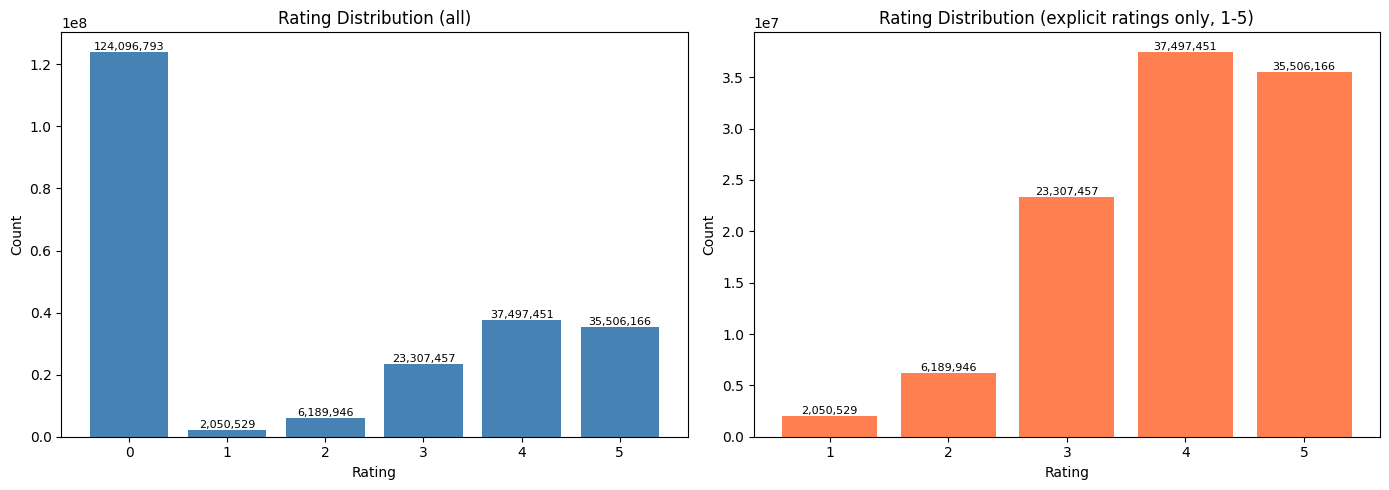

=== is_read distribution ===


+-------+---------+
|is_read|    count|
+-------+---------+
|      0|116517139|
|      1|112131203|
+-------+---------+

=== is_reviewed distribution ===


+-----------+---------+
|is_reviewed|    count|
+-----------+---------+
|          0|212429193|
|          1| 16219149|
+-----------+---------+



In [ ]:
# Rating distribution (including 0 = unrated)
rating_dist = (
    interactions.groupBy("rating").count()
    .orderBy("rating")
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution including 0
axes[0].bar(rating_dist["rating"], rating_dist["count"], color="steelblue")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")
axes[0].set_title("Rating Distribution (all)")
axes[0].set_xticks(range(6))
for i, row in rating_dist.iterrows():
    axes[0].text(row["rating"], row["count"], f'{row["count"]:,.0f}', ha="center", va="bottom", fontsize=8)

# Excluding 0 (only explicit ratings)
rated = rating_dist[rating_dist["rating"] > 0]
axes[1].bar(rated["rating"], rated["count"], color="coral")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Count")
axes[1].set_title("Rating Distribution (explicit ratings only, 1-5)")
axes[1].set_xticks(range(1, 6))
for _, row in rated.iterrows():
    axes[1].text(row["rating"], row["count"], f'{row["count"]:,.0f}', ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# is_read and is_reviewed breakdown
print("=== is_read distribution ===")
interactions.groupBy("is_read").count().orderBy("is_read").show()
print("=== is_reviewed distribution ===")
interactions.groupBy("is_reviewed").count().orderBy("is_reviewed").show()

## 4. User Activity Analysis

In [10]:
interactions.show(5)

+-------+-------+-------+------+-----------+
|user_id|book_id|is_read|rating|is_reviewed|
+-------+-------+-------+------+-----------+
|      0|    948|      1|     5|          0|
|      0|    947|      1|     5|          1|
|      0|    946|      1|     5|          0|
|      0|    945|      1|     5|          0|
|      0|    944|      1|     5|          0|
+-------+-------+-------+------+-----------+
only showing top 5 rows


In [4]:
# Interactions per user
user_activity = interactions.groupBy("user_id").agg(
    F.count("*").alias("n_interactions"),
    F.sum(F.col("rating").cast("int")).alias("total_rating_sum"),
    F.avg("rating").alias("avg_rating"),
    F.sum("is_read").alias("n_read"),
    F.sum("is_reviewed").alias("n_reviewed"),
    F.countDistinct("book_id").alias("n_unique_books"),
    F.sum(F.when(F.col("rating") > 0, 1).otherwise(0)).alias("n_rated"),
)

print("=== User activity summary ===")
user_activity.describe().show()

# Percentiles for interactions per user
print("=== Interactions per user: percentiles ===")
user_activity.select(
    F.expr("percentile_approx(n_interactions, array(0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99))").alias("percentiles")
).show(truncate=False)

=== User activity summary ===


+-------+-----------------+------------------+-----------------+-----------------+------------------+------------------+------------------+------------------+
|summary|          user_id|    n_interactions| total_rating_sum|       avg_rating|            n_read|        n_reviewed|    n_unique_books|           n_rated|
+-------+-----------------+------------------+-----------------+-----------------+------------------+------------------+------------------+------------------+
|  count|           876145|            876145|           876145|           876145|            876145|            876145|            876145|            876145|
|   mean|         438072.0|260.97089180443874|470.0973309212516|2.199945100236181|127.98247207939325|18.511946081984146|260.97089180443874|119.33133100114706|
| stddev|252921.4201370985| 746.8282281361628| 897.313303131977|1.272398308265033| 241.6128673776769| 88.96532711664119| 746.8282281361628|231.97846748319995|
|    min|                0|                 1|

+---------------------------------------+
|percentiles                            |
+---------------------------------------+
|[1, 3, 7, 32, 100, 265, 601, 959, 2367]|
+---------------------------------------+



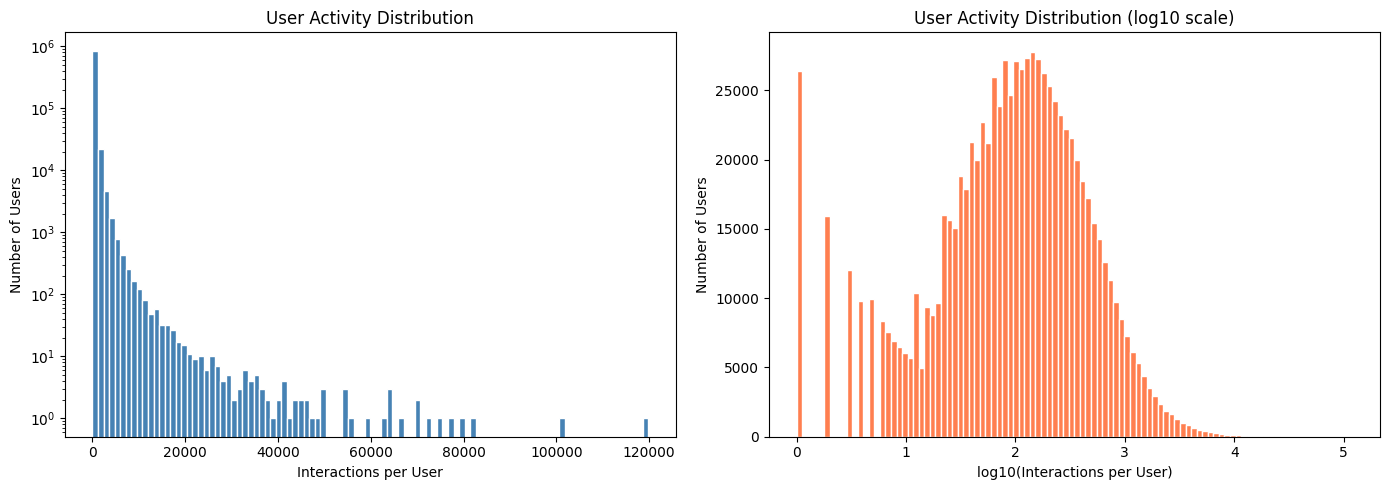

Users with <= 1 interactions: 26,404 (3.01%)


Users with <= 5 interactions: 74,046 (8.45%)


Users with <= 10 interactions: 109,428 (12.49%)


Users with <= 20 interactions: 158,285 (18.07%)


In [9]:
# User activity distribution (log-scale histogram)
user_act_pd = user_activity.select("n_interactions").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_act_pd["n_interactions"], bins=100, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Interactions per User")
axes[0].set_ylabel("Number of Users")
axes[0].set_title("User Activity Distribution")
axes[0].set_yscale("log")

axes[1].hist(np.log10(user_act_pd["n_interactions"].clip(lower=1)), bins=100, color="coral", edgecolor="white")
axes[1].set_xlabel("log10(Interactions per User)")
axes[1].set_ylabel("Number of Users")
axes[1].set_title("User Activity Distribution (log10 scale)")

plt.tight_layout()
plt.show()

# Cold-start users (few interactions)
for threshold in [1, 5, 10, 20]:
    cnt = user_activity.filter(F.col("n_interactions") <= threshold).count()
    print(f"Users with <= {threshold} interactions: {cnt:,} ({cnt/n_users*100:.2f}%)")

## 5. Book Popularity Analysis

In [ ]:
# Interactions per book
book_popularity = interactions.groupBy("book_id").agg(
    F.count("*").alias("n_interactions"),
    F.avg("rating").alias("avg_rating"),
    F.avg(F.when(F.col("rating") > 0, F.col("rating"))).alias("avg_rating_excl_zero"),
    F.sum(F.when(F.col("rating") > 0, 1).otherwise(0)).alias("n_rated"),
    F.sum("is_read").alias("n_read"),
    F.sum("is_reviewed").alias("n_reviewed"),
    F.countDistinct("user_id").alias("n_unique_users"),
)

print("=== Book popularity summary ===")
book_popularity.describe().show()

print("=== Interactions per book: percentiles ===")
book_popularity.select(
    F.expr("percentile_approx(n_interactions, array(0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99))").alias("percentiles")
).show(truncate=False)

In [ ]:
# Book popularity distribution
book_pop_pd = book_popularity.select("n_interactions").toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(book_pop_pd["n_interactions"], bins=100, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Interactions per Book")
axes[0].set_ylabel("Number of Books")
axes[0].set_title("Book Popularity Distribution")
axes[0].set_yscale("log")

axes[1].hist(np.log10(book_pop_pd["n_interactions"].clip(lower=1)), bins=100, color="coral", edgecolor="white")
axes[1].set_xlabel("log10(Interactions per Book)")
axes[1].set_ylabel("Number of Books")
axes[1].set_title("Book Popularity Distribution (log10 scale)")

plt.tight_layout()
plt.show()

# Cold-start books (few interactions)
for threshold in [1, 5, 10, 20]:
    cnt = book_popularity.filter(F.col("n_interactions") <= threshold).count()
    print(f"Books with <= {threshold} interactions: {cnt:,} ({cnt/n_books*100:.2f}%)")

# Top 20 most popular books
print("\n=== Top 20 most interacted books ===")
book_popularity.orderBy(F.desc("n_interactions")).show(20, truncate=False)

## 6. Books Dataset — Detailed Exploration

In [ ]:
# Books schema and sample
books.printSchema()
books.show(3, truncate=80, vertical=True)

In [ ]:
# Summary statistics for numeric columns in books
numeric_cols = [f.name for f in books.schema.fields if str(f.dataType) in ("IntegerType()", "LongType()", "DoubleType()", "FloatType()")]
if numeric_cols:
    print(f"Numeric columns: {numeric_cols}")
    books.select(numeric_cols).describe().show(truncate=False)

# Null counts for books
print("=== Books: null counts ===")
books.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in books.columns]).show(vertical=True)

In [ ]:
# Language distribution (top 20)
print("=== Top 20 languages ===")
books.groupBy("language_code").count().orderBy(F.desc("count")).show(20, truncate=False)

# Publication year distribution (if available)
# Try common column names for publication year
year_cols = [c for c in books.columns if "year" in c.lower() or "publication" in c.lower()]
print(f"Year-related columns: {year_cols}")

if year_cols:
    year_col = year_cols[0]
    year_dist = (
        books.filter(F.col(year_col).isNotNull() & (F.col(year_col) > 0))
        .groupBy(year_col).count()
        .orderBy(year_col)
        .toPandas()
    )
    plt.figure(figsize=(14, 5))
    plt.bar(year_dist[year_col], year_dist["count"], color="steelblue", width=1.0)
    plt.xlabel("Publication Year")
    plt.ylabel("Number of Books")
    plt.title("Publication Year Distribution")
    plt.tight_layout()
    plt.show()

In [ ]:
# Average rating distribution from books metadata
rating_cols = [c for c in books.columns if "average_rating" in c.lower() or "avg_rating" in c.lower() or c == "average_rating"]
print(f"Rating-related columns in books: {rating_cols}")

if rating_cols:
    avg_rat_col = rating_cols[0]
    avg_rating_pd = books.filter(F.col(avg_rat_col).isNotNull()).select(avg_rat_col).toPandas()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(avg_rating_pd[avg_rat_col], bins=50, color="steelblue", edgecolor="white")
    ax.set_xlabel("Average Rating")
    ax.set_ylabel("Number of Books")
    ax.set_title("Distribution of Average Book Ratings (from books metadata)")
    plt.tight_layout()
    plt.show()

# Number of pages distribution (if available)
page_cols = [c for c in books.columns if "page" in c.lower() or "num_pages" in c.lower()]
print(f"Page-related columns: {page_cols}")

if page_cols:
    page_col = page_cols[0]
    pages_pd = books.filter((F.col(page_col).isNotNull()) & (F.col(page_col) > 0) & (F.col(page_col) < 5000)).select(page_col).toPandas()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(pages_pd[page_col], bins=100, color="coral", edgecolor="white")
    ax.set_xlabel("Number of Pages")
    ax.set_ylabel("Number of Books")
    ax.set_title("Distribution of Book Page Counts (< 5000 pages)")
    plt.tight_layout()
    plt.show()

## 7. Interactions Dedup — Temporal Analysis

In [ ]:
# Explore interactions_dedup schema
interactions_dedup.printSchema()
interactions_dedup.show(5, truncate=80, vertical=True)

In [ ]:
# Identify timestamp column(s)
time_cols = [c for c in interactions_dedup.columns if any(k in c.lower() for k in ["time", "date", "stamp", "ts"])]
print(f"Time-related columns: {time_cols}")
print(f"All columns: {interactions_dedup.columns}")

# Summary stats
dedup_numeric = [f.name for f in interactions_dedup.schema.fields if str(f.dataType) in ("IntegerType()", "LongType()", "DoubleType()", "FloatType()")]
if dedup_numeric:
    interactions_dedup.select(dedup_numeric).describe().show(truncate=False)

# Null counts
interactions_dedup.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in interactions_dedup.columns]).show(vertical=True)

In [ ]:
# Temporal distribution of interactions
# Adapt column name based on what's found above
# Common names in this dataset: "date_added", "date_updated", "read_at", "started_at"
date_col_candidates = [c for c in interactions_dedup.columns if any(k in c.lower() for k in ["date", "time", "stamp"])]
print(f"Date column candidates: {date_col_candidates}")

if date_col_candidates:
    date_col = date_col_candidates[0]
    print(f"Using column: {date_col}")
    # Show sample values
    interactions_dedup.select(date_col).show(10, truncate=False)

    # Parse and extract year-month
    interactions_dedup_ts = interactions_dedup.withColumn(
        "date_parsed",
        F.coalesce(
            F.to_timestamp(F.col(date_col), "EEE MMM dd HH:mm:ss Z yyyy"),  # Twitter-like format
            F.to_timestamp(F.col(date_col)),  # default parsing
        )
    ).withColumn("year_month", F.date_format("date_parsed", "yyyy-MM"))

    # Monthly activity over time
    monthly = (
        interactions_dedup_ts
        .filter(F.col("year_month").isNotNull())
        .groupBy("year_month").count()
        .orderBy("year_month")
        .toPandas()
    )

    if len(monthly) > 0:
        plt.figure(figsize=(16, 5))
        plt.plot(range(len(monthly)), monthly["count"], color="steelblue", linewidth=1)
        # Show every 12th label
        step = max(1, len(monthly) // 20)
        plt.xticks(range(0, len(monthly), step), monthly["year_month"].iloc[::step], rotation=45)
        plt.xlabel("Year-Month")
        plt.ylabel("Number of Interactions")
        plt.title("Monthly Interaction Volume Over Time")
        plt.tight_layout()
        plt.show()
else:
    print("No date columns found in interactions_dedup.")

## 8. ID Maps — Join Validation

In [ ]:
# Check that interaction IDs are covered by the ID maps
interaction_user_ids = interactions.select("user_id").distinct()
interaction_book_ids = interactions.select("book_id").distinct()

map_user_ids = user_id_map.select(F.col("user_id_csv").alias("user_id")).distinct()
map_book_ids = book_id_map.select(F.col("book_id_csv").alias("book_id")).distinct()

# Users in interactions but not in user_id_map
orphan_users = interaction_user_ids.subtract(map_user_ids).count()
# Books in interactions but not in book_id_map
orphan_books = interaction_book_ids.subtract(map_book_ids).count()

print(f"Users in interactions not in user_id_map: {orphan_users:,}")
print(f"Books in interactions not in book_id_map: {orphan_books:,}")

# Coverage summary
print(f"\nUser coverage: {n_users - orphan_users:,} / {n_users:,} ({(n_users - orphan_users)/n_users*100:.2f}%)")
print(f"Book coverage: {n_books - orphan_books:,} / {n_books:,} ({(n_books - orphan_books)/n_books*100:.2f}%)")

# Check ID range alignment
print("\n=== ID range comparison ===")
print("interactions user_id range:")
interactions.select(F.min("user_id"), F.max("user_id")).show()
print("user_id_map user_id_csv range:")
user_id_map.select(F.min("user_id_csv"), F.max("user_id_csv")).show()
print("interactions book_id range:")
interactions.select(F.min("book_id"), F.max("book_id")).show()
print("book_id_map book_id_csv range:")
book_id_map.select(F.min("book_id_csv"), F.max("book_id_csv")).show()

## 9. Cross-Dataset Analysis: Interactions + Books

In [ ]:
# Join interactions with book metadata through the ID map
# interactions.book_id -> book_id_map.book_id_csv -> book_id_map.book_id -> books.book_id
interactions_with_books = (
    interactions
    .join(book_id_map, interactions["book_id"] == book_id_map["book_id_csv"], "inner")
    .drop("book_id_csv")
    .withColumnRenamed("book_id", "book_id_csv_orig")
    .join(books, book_id_map["book_id"] == books["book_id"], "inner")
)
print(f"Interactions successfully joined with books: {interactions_with_books.count():,}")
interactions_with_books.select("book_id_csv_orig", "book_id", "title", "rating", "average_rating", "language_code").show(10, truncate=60)

In [ ]:
# Top 20 most popular books by interaction count (with titles)
top_books = (
    interactions_with_books
    .groupBy("book_id", "title")
    .agg(
        F.count("*").alias("n_interactions"),
        F.avg("rating").alias("avg_user_rating"),
        F.avg(F.when(F.col("rating") > 0, F.col("rating"))).alias("avg_rating_excl_zero"),
    )
    .orderBy(F.desc("n_interactions"))
)
print("=== Top 20 Most Popular Books ===")
top_books.show(20, truncate=60)

# Top 20 highest-rated books (with min 100 ratings)
top_rated = (
    interactions_with_books
    .filter(F.col("rating") > 0)
    .groupBy("book_id", "title")
    .agg(
        F.count("*").alias("n_ratings"),
        F.avg("rating").alias("avg_rating"),
    )
    .filter(F.col("n_ratings") >= 100)
    .orderBy(F.desc("avg_rating"))
)
print("=== Top 20 Highest Rated Books (min 100 ratings) ===")
top_rated.show(20, truncate=60)

In [ ]:
# Rating behavior by language
rating_by_lang = (
    interactions_with_books
    .filter((F.col("rating") > 0) & (F.col("language_code").isNotNull()) & (F.col("language_code") != ""))
    .groupBy("language_code")
    .agg(
        F.count("*").alias("n_ratings"),
        F.avg("rating").alias("avg_rating"),
    )
    .filter(F.col("n_ratings") >= 1000)
    .orderBy(F.desc("n_ratings"))
)
print("=== Average Rating by Language (min 1000 ratings) ===")
rating_by_lang.show(20, truncate=False)

# Plot
lang_pd = rating_by_lang.limit(15).toPandas()
fig, ax1 = plt.subplots(figsize=(12, 5))
x = range(len(lang_pd))
ax1.bar(x, lang_pd["n_ratings"], color="steelblue", alpha=0.7, label="# Ratings")
ax1.set_ylabel("Number of Ratings", color="steelblue")
ax1.set_xticks(x)
ax1.set_xticklabels(lang_pd["language_code"], rotation=45)

ax2 = ax1.twinx()
ax2.plot(x, lang_pd["avg_rating"], "ro-", label="Avg Rating")
ax2.set_ylabel("Average Rating", color="red")
ax2.set_ylim(1, 5)

plt.title("Ratings Volume and Average by Language (Top 15)")
fig.legend(loc="upper right", bbox_to_anchor=(0.95, 0.95))
plt.tight_layout()
plt.show()

## 10. Recommendation System Readiness Summary

In [ ]:
# Explicit ratings only (rating > 0) — key subset for collaborative filtering
explicit = interactions.filter(F.col("rating") > 0)
n_explicit = explicit.count()
n_explicit_users = explicit.select("user_id").distinct().count()
n_explicit_books = explicit.select("book_id").distinct().count()

print("=" * 60)
print("  RECOMMENDATION SYSTEM READINESS SUMMARY")
print("=" * 60)
print(f"\nTotal interactions:          {n_total:>15,}")
print(f"Explicit ratings (1-5):      {n_explicit:>15,}  ({n_explicit/n_total*100:.1f}%)")
print(f"Implicit signals (rating=0): {n_total - n_explicit:>15,}  ({(n_total-n_explicit)/n_total*100:.1f}%)")
print(f"\nAll interactions:")
print(f"  Unique users:              {n_users:>15,}")
print(f"  Unique books:              {n_books:>15,}")
print(f"  Avg interactions/user:     {n_total/n_users:>15,.1f}")
print(f"  Avg interactions/book:     {n_total/n_books:>15,.1f}")
print(f"  Sparsity:                  {1 - n_total/(n_users*n_books):>15.6f}")
print(f"\nExplicit ratings only:")
print(f"  Unique users:              {n_explicit_users:>15,}")
print(f"  Unique books:              {n_explicit_books:>15,}")
print(f"  Avg ratings/user:          {n_explicit/n_explicit_users:>15,.1f}")
print(f"  Avg ratings/book:          {n_explicit/n_explicit_books:>15,.1f}")
print(f"  Sparsity:                  {1 - n_explicit/(n_explicit_users*n_explicit_books):>15.6f}")

# Power-law check: fraction of interactions from top users/books
print("\n=== Concentration analysis ===")
user_act_sorted = user_activity.orderBy(F.desc("n_interactions"))
top_1pct_users = int(n_users * 0.01)
top_1pct_interactions = user_act_sorted.limit(top_1pct_users).agg(F.sum("n_interactions")).collect()[0][0]
print(f"Top 1% of users ({top_1pct_users:,}) account for {top_1pct_interactions:,} interactions ({top_1pct_interactions/n_total*100:.1f}%)")

book_pop_sorted = book_popularity.orderBy(F.desc("n_interactions"))
top_1pct_books = int(n_books * 0.01)
top_1pct_book_interactions = book_pop_sorted.limit(top_1pct_books).agg(F.sum("n_interactions")).collect()[0][0]
print(f"Top 1% of books ({top_1pct_books:,}) account for {top_1pct_book_interactions:,} interactions ({top_1pct_book_interactions/n_total*100:.1f}%)")